In [63]:
from astroquery.mast import Observations
from astropy.time import Time
import numpy as np
from matplotlib import pyplot as pl
from astropy.io import fits
from astropy.wcs import WCS
import fsspec
import s3fs
from regions import CircleSkyRegion, CirclePixelRegion, PolygonSkyRegion, Regions
from mocpy import MOC
from mocpy import WCS as mocWCS
import pprint
import astropy.units as u
import astropy.constants as const
from astropy.coordinates import Angle, SkyCoord
import matplotlib.pyplot as plt
import matplotlib
from astropy.table import Table

In [86]:
# # ra = 53.13211333333333
# # dec = -27.79680777777778
# # rad = 0.008333
# a

nexus_candidates = Table.read('~/Documents/Talks/2025_SN100/NexusCandidates.txt', format='ascii')
nexus_coords = SkyCoord(nexus_candidates['RA'], nexus_candidates['Dec'], unit="deg", frame="icrs")
print(len(nexus_coords))

nexus_candidates2 = Table.read('~/Documents/Talks/2025_SN100/NexusCandidates2.txt', format='ascii')
nexus_coords2 = SkyCoord(nexus_candidates2['RA'], nexus_candidates2['Dec'], unit="deg", frame="icrs")
print(len(nexus_coords2))

21
11


In [7]:
obs_table = Observations.query_criteria(
                                        # coordinates=f'{ra} {dec}',
                                        # radius=f"{rad} deg",
                                        instrument_name=['NIRCAM','NIRCAM/IMAGE'],
                                        # proposal_id = ['1180'],
                                        proposal_id = ['5105'],
                                        calib_level=["3"],
                                        filters=['F200W','F444W']
                                        )

In [68]:
pprint.pprint(obs_table.columns)
pprint.pprint(obs_table['filters'])

<TableColumns names=('intentType','obs_collection','provenance_name','instrument_name','project','filters','wavelength_region','target_name','target_classification','obs_id','s_ra','s_dec','dataproduct_type','proposal_pi','calib_level','t_min','t_max','t_exptime','em_min','em_max','obs_title','t_obs_release','proposal_id','proposal_type','sequence_number','s_region','jpegURL','dataURL','dataRights','mtFlag','srcDen','obsid','objID')>
<MaskedColumn name='filters' dtype='str5' length=10>
F444W
F200W
F200W
F444W
F200W
F444W
F444W
F200W
F200W
F444W


In [75]:
# print(obs_table["s_region"])

nexus_regions = obs_table["s_region"]
nexus_ras = obs_table["s_ra"]
nexus_decs = obs_table["s_dec"]
nexus_filts = obs_table["filters"]
nexus_mocs_F200 = []
nexus_mocs_F444 = []

# avg_ra = np.mean(nexus_ras)
# avg_dec = np.mean(nexus_decs)
# avg_coord = np.

for nr, nra, ndec, filt in zip(nexus_regions, nexus_ras, nexus_decs, nexus_filts):
    
    cen_coord = SkyCoord(nra, ndec, unit="deg", frame="icrs")
    
    poly_str = nr.replace("J2000", "")
    poly_str = "fk5\n" + str(poly_str)
    # print(poly_str)
    r = Regions.parse(poly_str, format='ds9')
    # print(r)
    # 
    nex_moc = MOC.from_polygon_skycoord(r[0].vertices, max_depth=20)
    
    if filt == 'F200W':
        nexus_mocs_F200.append(nex_moc)
    else:
        nexus_mocs_F444.append(nex_moc)

f200W_moc_union = nexus_mocs_F200[0]
for nm in nexus_mocs_F200:
    f200W_moc_union = f200W_moc_union.union(nm)
    
f444W_moc_union = nexus_mocs_F444[0]
for nm in nexus_mocs_F444:
    f444W_moc_union = f444W_moc_union.union(nm)
    
moc_union = f200W_moc_union.union(f444W_moc_union)

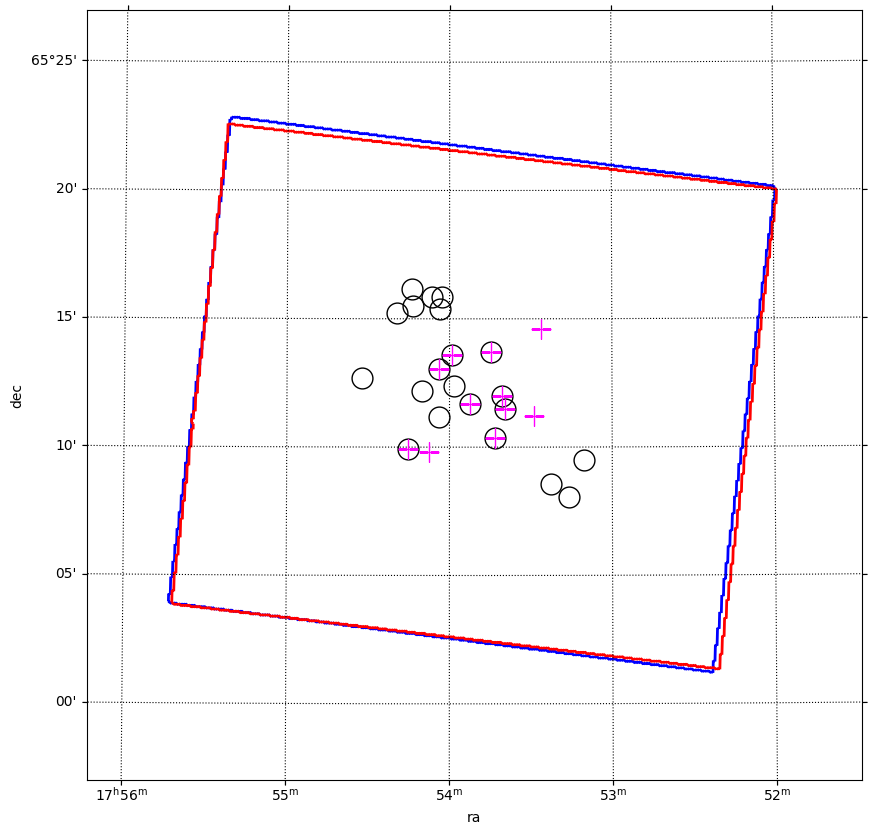

Total unique NEXUS area : 0.1127 sq deg


In [88]:
fig = plt.figure(111, figsize=(10,10))

# Define a astropy WCS easily
with mocWCS(
    fig,
    fov=0.5*u.deg,
    center=moc_union.barycenter(),
    coordsys="icrs",
    rotation=Angle(0, u.degree),
    # The gnomonic projection transforms great circles into straight lines.
    projection="TAN"
) as wcs:
    ax = fig.add_subplot(1, 1, 1, projection=wcs) # wcs

    # moc_union.border(ax=ax, wcs=wcs, alpha=1.0, fill=False, color="blue", linewidth=2)
    f200W_moc_union.border(ax=ax, wcs=wcs, alpha=1.0, fill=False, color="blue", linewidth=2)
    f444W_moc_union.border(ax=ax, wcs=wcs, alpha=1.0, fill=False, color="red", linewidth=2)
    
    for c in nexus_coords:
        ax.plot(c.ra.degree, c.dec.degree, 'o', color="black", markerfacecolor="None", markersize=15, transform=ax.get_transform("world"), label='Nexus Candidates', alpha=1.0)
        
    for c in nexus_coords2:
        ax.plot(c.ra.degree, c.dec.degree, '+', color="magenta", markerfacecolor="None", markersize=15, transform=ax.get_transform("world"), label='Nexus Candidates', alpha=1.0)
    # for n in nexus_mocs:
    #     n.border(ax=ax, wcs=wcs, alpha=0.8, fill=False, color="red", linewidth=2)
    
    # edff_moc.border(ax=ax, wcs=wcs, alpha=1.0, fill=False, color="green", linewidth=2)

plt.xlabel("ra")
plt.ylabel("dec")
# plt.title("EDFF")
plt.grid(color="black", linestyle="dotted")
plt.show()

nexus_covered = moc_union.sky_fraction*41253*u.deg**2
print("Total unique NEXUS area : %0.4f sq deg" % nexus_covered.value)

In [29]:
|product_table = Observations.get_product_list(obs_table)
len(product_table)

60026

In [28]:
print(product_table['s_region'])

KeyError: 's_region'

In [31]:
prod = Observations.get_unique_product_list(obs_table)
print(len(prod))

INFO: 44454 of 60026 products were duplicates. Only returning 15572 unique product(s). [astroquery.mast.utils]
INFO: To return all products, use `Observations.get_product_list` [astroquery.mast.observations]
15572


In [32]:
products = Observations.filter_products(prod,
                                        productSubGroupDescription=["CAL"],
                                        extension="fits")



In [ ]:
# manifest = Observations.download_products(products)

In [34]:
print(len(products))
products[0]['s_region']

1032


KeyError: 's_region'

In [17]:
%%time
f = 'jw05105001001_05101_00001_nrca1'
s3_fits_url = "s3://stpubdata/jwst/public/jw01180/jw01180013001/jw01180013001_02101_00001_nrca1_cal.fits"

fsspec_kwargs = {"anon": True} 

try:

    header = fits.getheader(s3_fits_url, extname='SCI', use_fsspec=True, fsspec_kwargs=fsspec_kwargs)

except Exception as e:
    print(f"Error: {e}")


Error: stpubdata/jwst/public/jw01180/jw01180013001/jw05105001001_05101_00001_nrca1_cal.fits
CPU times: user 6.09 ms, sys: 2.73 ms, total: 8.82 ms
Wall time: 492 ms


In [23]:
%%time
f = 'jw05105001001_05101_00001_nrca1'
s3_fits_url = "s3://stpubdata/jwst/public/jw05105/jw05105001001/%s_cal.fits" % f

fsspec_kwargs = {"anon": True} 
header = None
try:

    header = fits.getheader(s3_fits_url, extname='SCI', use_fsspec=True, fsspec_kwargs=fsspec_kwargs)
    # print(header)
except Exception as e:
    print(f"Error: {e}")

WCS(header).calc_footprint()


CPU times: user 502 ms, sys: 250 ms, total: 752 ms
Wall time: 1min 5s


array([[268.49562049,  65.19947883],
       [268.53782287,  65.19758859],
       [268.54267468,  65.21506469],
       [268.5004121 ,  65.21720555]])

In [22]:
WCS(header).calc_footprint()

Set DATE-AVG to '2024-09-12T15:47:56.584' from MJD-AVG.
Set DATE-END to '2024-09-12T15:53:07.950' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to     0.962632 from OBSGEO-[XYZ].
Set OBSGEO-H to 1261525911.411 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


array([[268.49562049,  65.19947883],
       [268.53782287,  65.19758859],
       [268.54267468,  65.21506469],
       [268.5004121 ,  65.21720555]])

In [92]:
PRIMER='1837'
# primer_obs_table = Observations.query_criteria(
#                                         instrument_name=['NIRCAM','NIRCAM/IMAGE'],
#                                         proposal_id = [PRIMER],
#                                         calib_level=["3"],
#                                         filters=['F115W','F150W', 'F277W', 'F444W']
#                                         )
primer_obs_table_f115w = Observations.query_criteria(
                                        instrument_name=['NIRCAM','NIRCAM/IMAGE'],
                                        proposal_id = [PRIMER],
                                        calib_level=["3"],
                                        filters=['F115W']
                                        )

KeyboardInterrupt: 

In [1]:
# Old code:
ra = 53.0840400
dec = -27.839346
rad = 0.016
filters = ["F182M", "F210M", "F335M"]

obs_table = Observations.query_criteria(
                                        coordinates=f'{ra} {dec}',
                                        radius=f"{rad} deg",
                                        instrument_name=['NIRCAM','NIRCAM/IMAGE'],
#                                         proposal_id = ['1180'],
                                        calib_level=["3"],
                                        filters=filters
                                        )
print(len(obs_table))

products = Observations.get_unique_product_list(obs_table)

selected_products = Observations.filter_products(prod,
                                        productSubGroupDescription=["RATE"],
                                        extension="fits")
print(len(selected_products))

download_dir = '/astro/armin/data/mgriggio/davesbb/'
manifest = Observations.download_products(selected_products, flat=True, download_dir=download_dir)